# MediaPipe + LSTM Classification Model
## ADSP 32023 - Advanced Computer Vision Using Deep Learning
## Spring 2026

In [ ]:
# ============================================================
# 0. Install packages
# ============================================================
!pip install -q torch torchvision torchaudio coremltools scikit-learn matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.2 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 1. Imports
# ============================================================
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from google.colab import drive

import coremltools as ct

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [ ]:
# ============================================================
# 2. Paths + config
# ============================================================
drive.mount("/content/drive")
PROJECT_DIR = "/content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project/"

SAVE_DIR = os.path.join(PROJECT_DIR, "data", "preprocessed")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
GRAPH_DIR = os.path.join(PROJECT_DIR, "graphs")
RESULT_DIR = os.path.join(PROJECT_DIR, "data")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

EXPERIMENT_NAME = "torch_lstm_coreml"
OUTPUT_MODEL_DIR = os.path.join(MODEL_DIR, EXPERIMENT_NAME)
OUTPUT_GRAPH_DIR = os.path.join(GRAPH_DIR, EXPERIMENT_NAME)
OUTPUT_RESULT_DIR = os.path.join(RESULT_DIR, EXPERIMENT_NAME)
os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_GRAPH_DIR, exist_ok=True)
os.makedirs(OUTPUT_RESULT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 80
N_SPLITS = 5

HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.30
LR = 1e-3
WEIGHT_DECAY = 1e-5

Mounted at /content/drive


In [ ]:
# ============================================================
# 3. Load new extracted MediaPipe data
# ============================================================
X_verified = np.load(os.path.join(SAVE_DIR, "X_verified_mediapipe.npy"))
y_verified = np.load(os.path.join(SAVE_DIR, "y_verified.npy"))

X_test = np.load(os.path.join(SAVE_DIR, "X_test_mediapipe.npy"))
y_test = np.load(os.path.join(SAVE_DIR, "y_test.npy"))

kept_verified_df = pd.read_csv(os.path.join(SAVE_DIR, "kept_verified_mediapipe_dataset.csv"))
kept_test_df = pd.read_csv(os.path.join(SAVE_DIR, "kept_test_mediapipe_dataset.csv"))

with open(os.path.join(SAVE_DIR, "label_names.json"), "r") as f:
    label_names = json.load(f)

num_classes = len(label_names)
SEQUENCE_LENGTH = X_verified.shape[1]
FEATURE_SIZE = X_verified.shape[2]

print("X_verified:", X_verified.shape)
print("y_verified:", y_verified.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("SEQUENCE_LENGTH:", SEQUENCE_LENGTH)
print("FEATURE_SIZE:", FEATURE_SIZE)
print("num_classes:", num_classes)
print(label_names)

X_verified: (11897, 48, 300)
y_verified: (11897,)
X_test: (1293, 48, 300)
y_test: (1293,)
SEQUENCE_LENGTH: 48
FEATURE_SIZE: 300
num_classes: 21
['barbell biceps curl', 'bench press', 'chest fly machine', 'deadlift', 'decline bench press', 'hammer curl', 'hip thrust', 'incline bench press', 'lat pulldown', 'lateral raise', 'leg extension', 'leg raises', 'pull Up', 'push-up', 'romanian deadlift', 'russian twist', 'shoulder press', 'squat', 't bar row', 'tricep Pushdown', 'tricep dips']


In [ ]:
# ============================================================
# 4. Scaling + augmentation helpers
# ============================================================
def scale_sequence_data(X_train, X_val):
    n_train, t, f = X_train.shape
    n_val = X_val.shape[0]

    scaler = StandardScaler()

    X_train_flat = X_train.reshape(-1, f)
    X_val_flat = X_val.reshape(-1, f)

    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(n_train, t, f)
    X_val_scaled = scaler.transform(X_val_flat).reshape(n_val, t, f)

    return X_train_scaled.astype(np.float32), X_val_scaled.astype(np.float32), scaler


def scale_with_existing_scaler(X, scaler):
    n, t, f = X.shape
    X_flat = X.reshape(-1, f)
    X_scaled = scaler.transform(X_flat).reshape(n, t, f)
    return X_scaled.astype(np.float32)


def augment_sequence(
    seq,
    noise_std=0.015,
    scale_std=0.025,
    dropout_prob=0.06,
    time_shift_max=4,
    time_mask_prob=0.15,
    time_mask_max=5,
    feature_mask_prob=0.04
):
    aug = seq.copy()

    aug += np.random.normal(0, noise_std, size=aug.shape)
    aug *= np.random.normal(1.0, scale_std)

    shift = np.random.randint(-time_shift_max, time_shift_max + 1)
    aug = np.roll(aug, shift=shift, axis=0)

    for i in range(1, len(aug)):
        if np.random.rand() < dropout_prob:
            aug[i] = aug[i - 1]

    if np.random.rand() < time_mask_prob:
        mask_len = np.random.randint(1, time_mask_max + 1)
        start = np.random.randint(0, max(1, len(aug) - mask_len))
        replacement = aug[start - 1] if start > 0 else aug[start]
        aug[start:start + mask_len] = replacement

    feature_mask = np.random.rand(aug.shape[1]) < feature_mask_prob
    aug[:, feature_mask] = 0

    return aug.astype(np.float32)


def make_augmented_training_data(X_train, y_train, copies=2):
    X_list = [X_train]
    y_list = [y_train]

    for _ in range(copies):
        X_aug = np.array([augment_sequence(seq) for seq in X_train], dtype=np.float32)
        X_list.append(X_aug)
        y_list.append(y_train)

    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

In [ ]:
# ============================================================
# 5. PyTorch LSTM + Attention model
# ============================================================
class WorkoutClassifierLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        self.layer_norm = nn.LayerNorm(hidden_size * 2)
        self.attention = nn.Linear(hidden_size * 2, 1)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        lstm_out = self.layer_norm(lstm_out)

        attn_scores = self.attention(lstm_out)
        attn_weights = torch.softmax(attn_scores, dim=1)

        context = torch.sum(lstm_out * attn_weights, dim=1)
        logits = self.classifier(context)

        return logits


def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(model)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")

In [ ]:
# ============================================================
# 6. Training helpers
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)

        correct += predicted.eq(batch_y).sum().item()
        total += batch_y.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            total_loss += loss.item()

            _, predicted = outputs.max(1)

            correct += predicted.eq(batch_y).sum().item()
            total += batch_y.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

In [ ]:
# ============================================================
# 7. Train with GroupKFold on verified data
# ============================================================
gkf = GroupKFold(n_splits=N_SPLITS)
groups = kept_verified_df["filepath"].values

fold_accuracies = []
fold_macro_f1 = []
fold_weighted_f1 = []

all_true = []
all_pred = []

best_val_acc = 0
best_model_state = None
best_scaler = None
best_history = None
best_fold = None

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X_verified, y_verified, groups=groups),
    start=1
):
    print(f"\n================ Fold {fold} ================")

    X_train_raw = X_verified[train_idx]
    X_val_raw = X_verified[val_idx]

    y_train = y_verified[train_idx]
    y_val = y_verified[val_idx]

    X_train, X_val, scaler = scale_sequence_data(X_train_raw, X_val_raw)

    X_train_aug, y_train_aug = make_augmented_training_data(
        X_train,
        y_train,
        copies=2
    )

    train_dataset = TensorDataset(
        torch.FloatTensor(X_train_aug),
        torch.LongTensor(y_train_aug)
    )

    val_dataset = TensorDataset(
        torch.FloatTensor(X_val),
        torch.LongTensor(y_val)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = WorkoutClassifierLSTM(
        input_size=FEATURE_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        num_classes=num_classes,
        dropout=DROPOUT
    ).to(DEVICE)

    if fold == 1:
        count_parameters(model)

    class_weights_arr = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train_aug),
        y=y_train_aug
    )
    class_weights_tensor = torch.FloatTensor(class_weights_arr).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    optimizer = optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=5,
        factor=0.5
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    fold_best_acc = 0
    fold_best_state = None
    patience = 15
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE
        )

        val_loss, val_acc, val_preds, val_labels = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > fold_best_acc:
            fold_best_acc = val_acc
            fold_best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:03d}/{EPOCHS} | "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
            )

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(fold_best_state)
    model = model.to(DEVICE)

    val_loss, val_acc, val_preds, val_labels = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    macro = f1_score(val_labels, val_preds, average="macro")
    weighted = f1_score(val_labels, val_preds, average="weighted")

    fold_accuracies.append(val_acc)
    fold_macro_f1.append(macro)
    fold_weighted_f1.append(weighted)

    all_true.extend(val_labels)
    all_pred.extend(val_preds)

    print(f"\nFold {fold} Best Accuracy: {val_acc:.4f}")
    print(f"Fold {fold} Macro F1: {macro:.4f}")
    print(f"Fold {fold} Weighted F1: {weighted:.4f}")

    print(classification_report(
        val_labels,
        val_preds,
        target_names=label_names,
        zero_division=0
    ))

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }
        best_scaler = scaler
        best_history = history
        best_fold = fold

print("\n================ Overall CV Results ================")
print("Mean Accuracy:", np.mean(fold_accuracies))
print("Mean Macro F1:", np.mean(fold_macro_f1))
print("Mean Weighted F1:", np.mean(fold_weighted_f1))
print("Best Fold:", best_fold)
print("Best Fold Accuracy:", best_val_acc)


================ Fold 1 ================
WorkoutClassifierLSTM(
  (lstm): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (attention): Linear(in_features=512, out_features=1, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=21, bias=True)
  )
)
Total params: 2,888,214
Trainable params: 2,888,214
Epoch 001/80 | Train Loss: 0.6795 | Train Acc: 0.7789 | Val Loss: 0.9103 | Val Acc: 0.7945
Epoch 005/80 | Train Loss: 0.1008 | Train Acc: 0.9730 | Val Loss: 1.0772 | Val Acc: 0.8496
Epoch 010/80 | Train Loss: 0.0098 | Train Acc: 0.9979 | Val Loss: 1.8395 | Val Acc: 0.8462
Epoch 015/80 | Train Loss: 0.0040 | Train Acc: 0.9989 |

,fold,accuracy,macro_f1,weighted_f1
0,1,0.870588,0.866010,0.868689
1,2,0.871429,0.867529,0.870840
2,3,0.879361,0.876369,0.880142
3,4,0.846154,0.848358,0.846460
4,5,0.888609,0.885030,0.888356


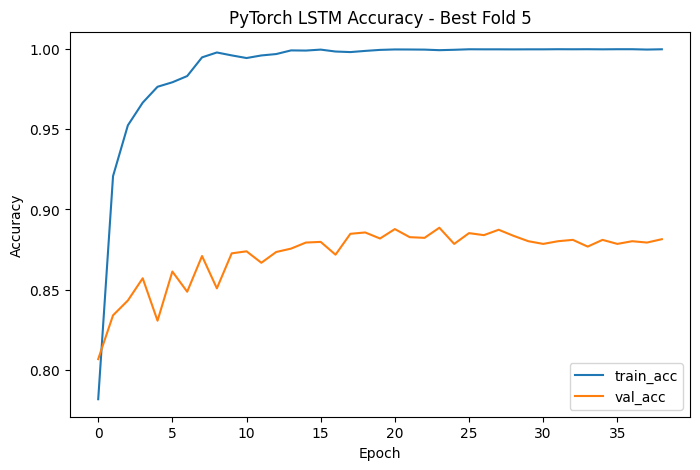

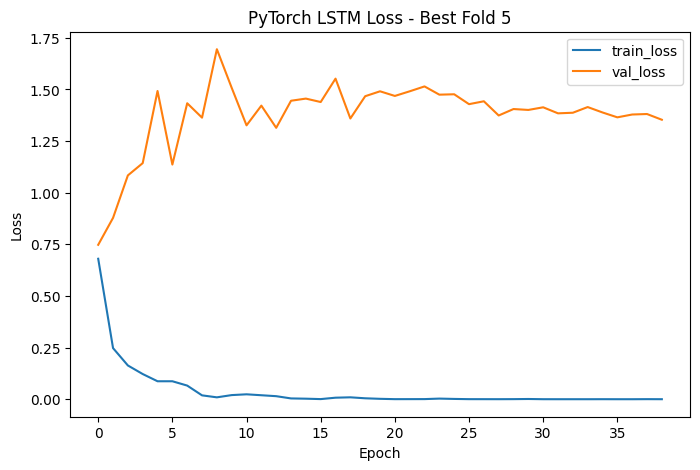

In [ ]:
# ============================================================
# 8. Save CV results + plots
# ============================================================
results_df = pd.DataFrame({
    "fold": list(range(1, len(fold_accuracies) + 1)),
    "accuracy": fold_accuracies,
    "macro_f1": fold_macro_f1,
    "weighted_f1": fold_weighted_f1
})

CV_RESULTS_PATH = os.path.join(OUTPUT_RESULT_DIR, "torch_lstm_cv_results.csv")
results_df.to_csv(CV_RESULTS_PATH, index=False)
display(results_df)

plt.figure(figsize=(8, 5))
plt.plot(best_history["train_acc"], label="train_acc")
plt.plot(best_history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"PyTorch LSTM Accuracy - Best Fold {best_fold}")
plt.legend()
ACC_PLOT_PATH = os.path.join(OUTPUT_GRAPH_DIR, "torch_lstm_accuracy.png")
plt.savefig(ACC_PLOT_PATH, dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(best_history["train_loss"], label="train_loss")
plt.plot(best_history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"PyTorch LSTM Loss - Best Fold {best_fold}")
plt.legend()
LOSS_PLOT_PATH = os.path.join(OUTPUT_GRAPH_DIR, "torch_lstm_loss.png")
plt.savefig(LOSS_PLOT_PATH, dpi=200, bbox_inches="tight")
plt.show()

,precision,recall,f1-score,support
barbell biceps curl,0.712975,0.756606,0.734143,719.000000
bench press,0.684426,0.648544,0.666002,515.000000
chest fly machine,0.943457,0.928458,0.935897,629.000000
deadlift,0.841418,0.846154,0.843779,533.000000
decline bench press,0.877174,0.870550,0.873849,927.000000
hammer curl,0.790909,0.814171,0.802372,748.000000
hip thrust,0.925101,0.862264,0.892578,530.000000
incline bench press,0.862069,0.898520,0.879917,473.000000
lat pulldown,0.821705,0.850267,0.835742,374.000000
lateral raise,0.932243,0.908884,0.920415,439.000000


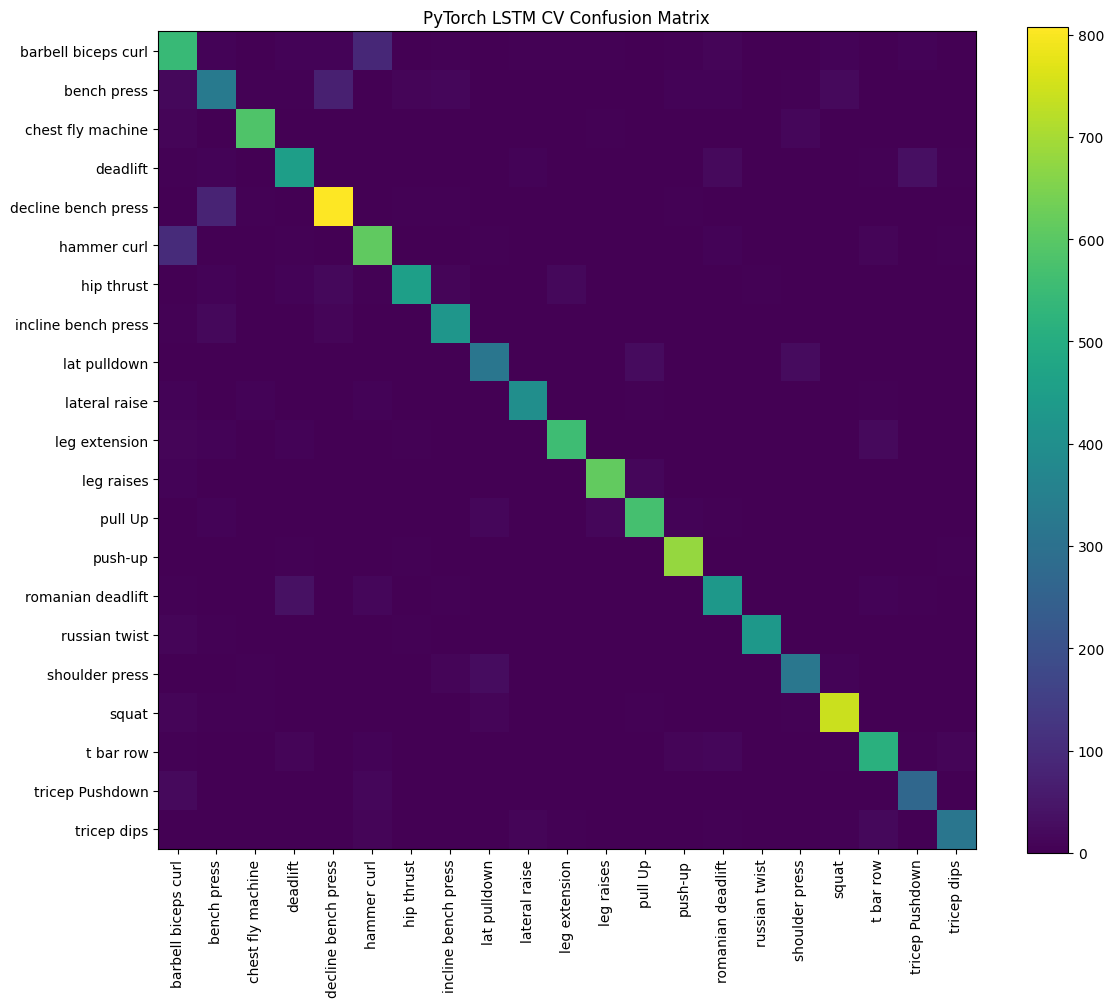

In [ ]:
# ============================================================
# 9. Classification report + confusion matrix on CV predictions
# ============================================================
overall_report = classification_report(
    all_true,
    all_pred,
    target_names=label_names,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(overall_report).transpose()
REPORT_PATH = os.path.join(OUTPUT_RESULT_DIR, "torch_lstm_cv_classification_report.csv")
report_df.to_csv(REPORT_PATH)
display(report_df)

cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.title("PyTorch LSTM CV Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(label_names)), label_names, rotation=90)
plt.yticks(range(len(label_names)), label_names)
plt.tight_layout()

CM_PNG_PATH = os.path.join(OUTPUT_GRAPH_DIR, "torch_lstm_cv_confusion_matrix.png")
plt.savefig(CM_PNG_PATH, dpi=200, bbox_inches="tight")
plt.show()

np.save(os.path.join(OUTPUT_RESULT_DIR, "torch_lstm_cv_confusion_matrix.npy"), cm)

In [ ]:
# ============================================================
# 10. Retrain final model on ALL verified data using best-style setup
# ============================================================
final_scaler = StandardScaler()

n, t, f = X_verified.shape
X_verified_flat = X_verified.reshape(-1, f)
X_verified_scaled = final_scaler.fit_transform(X_verified_flat).reshape(n, t, f).astype(np.float32)

X_verified_aug, y_verified_aug = make_augmented_training_data(
    X_verified_scaled,
    y_verified,
    copies=2
)

train_dataset = TensorDataset(
    torch.FloatTensor(X_verified_aug),
    torch.LongTensor(y_verified_aug)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

final_model = WorkoutClassifierLSTM(
    input_size=FEATURE_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=num_classes,
    dropout=DROPOUT
).to(DEVICE)

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_verified_aug),
    y=y_verified_aug
)
class_weights_tensor = torch.FloatTensor(class_weights_arr).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.Adam(
    final_model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

FINAL_EPOCHS = 40

final_history = {
    "train_loss": [],
    "train_acc": []
}

for epoch in range(1, FINAL_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        final_model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    final_history["train_loss"].append(train_loss)
    final_history["train_acc"].append(train_acc)

    if epoch == 1 or epoch % 5 == 0:
        print(f"Final Epoch {epoch:03d}/{FINAL_EPOCHS} | Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")

final_model.eval()

Final Epoch 001/40 | Loss: 0.6342 | Acc: 0.8000
Final Epoch 005/40 | Loss: 0.0961 | Acc: 0.9757
Final Epoch 010/40 | Loss: 0.0536 | Acc: 0.9890
Final Epoch 015/40 | Loss: 0.0435 | Acc: 0.9907
Final Epoch 020/40 | Loss: 0.0384 | Acc: 0.9922
Final Epoch 025/40 | Loss: 0.0357 | Acc: 0.9925
Final Epoch 030/40 | Loss: 0.0359 | Acc: 0.9935
Final Epoch 035/40 | Loss: 0.0241 | Acc: 0.9952
Final Epoch 040/40 | Loss: 0.0273 | Acc: 0.9950


WorkoutClassifierLSTM(
  (lstm): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (attention): Linear(in_features=512, out_features=1, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=21, bias=True)
  )
)

In [ ]:
# ============================================================
# 11. Evaluate final model on official test split
# ============================================================
X_test_scaled = scale_with_existing_scaler(X_test, final_scaler)

test_dataset = TensorDataset(
    torch.FloatTensor(X_test_scaled),
    torch.LongTensor(y_test)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loss, test_acc, test_preds, test_labels = evaluate(
    final_model,
    test_loader,
    criterion,
    DEVICE
)

test_macro = f1_score(test_labels, test_preds, average="macro")
test_weighted = f1_score(test_labels, test_preds, average="weighted")

print("Official Test Accuracy:", test_acc)
print("Official Test Macro F1:", test_macro)
print("Official Test Weighted F1:", test_weighted)

print(classification_report(
    test_labels,
    test_preds,
    target_names=label_names,
    zero_division=0
))

Official Test Accuracy: 0.5939675174013921
Official Test Macro F1: 0.5699814323980574
Official Test Weighted F1: 0.5857044070979359
                     precision    recall  f1-score   support

barbell biceps curl       0.30      0.76      0.43        49
        bench press       0.26      0.75      0.38        36
  chest fly machine       0.60      0.63      0.61        89
           deadlift       0.72      0.76      0.74       156
decline bench press       0.55      0.47      0.51        83
        hammer curl       0.00      0.00      0.00        49
         hip thrust       0.73      0.74      0.74        70
incline bench press       0.08      0.03      0.04        77
       lat pulldown       0.79      0.32      0.46        34
      lateral raise       0.42      0.62      0.50        26
      leg extension       0.66      0.97      0.79        36
         leg raises       0.96      0.76      0.85        70
            pull Up       0.70      0.77      0.73        62
            p

,precision,recall,f1-score,support
barbell biceps curl,0.298387,0.755102,0.427746,49.000000
bench press,0.257143,0.750000,0.382979,36.000000
chest fly machine,0.595745,0.629213,0.612022,89.000000
deadlift,0.716867,0.762821,0.739130,156.000000
decline bench press,0.549296,0.469880,0.506494,83.000000
hammer curl,0.000000,0.000000,0.000000,49.000000
hip thrust,0.732394,0.742857,0.737589,70.000000
incline bench press,0.080000,0.025974,0.039216,77.000000
lat pulldown,0.785714,0.323529,0.458333,34.000000
lateral raise,0.421053,0.615385,0.500000,26.000000


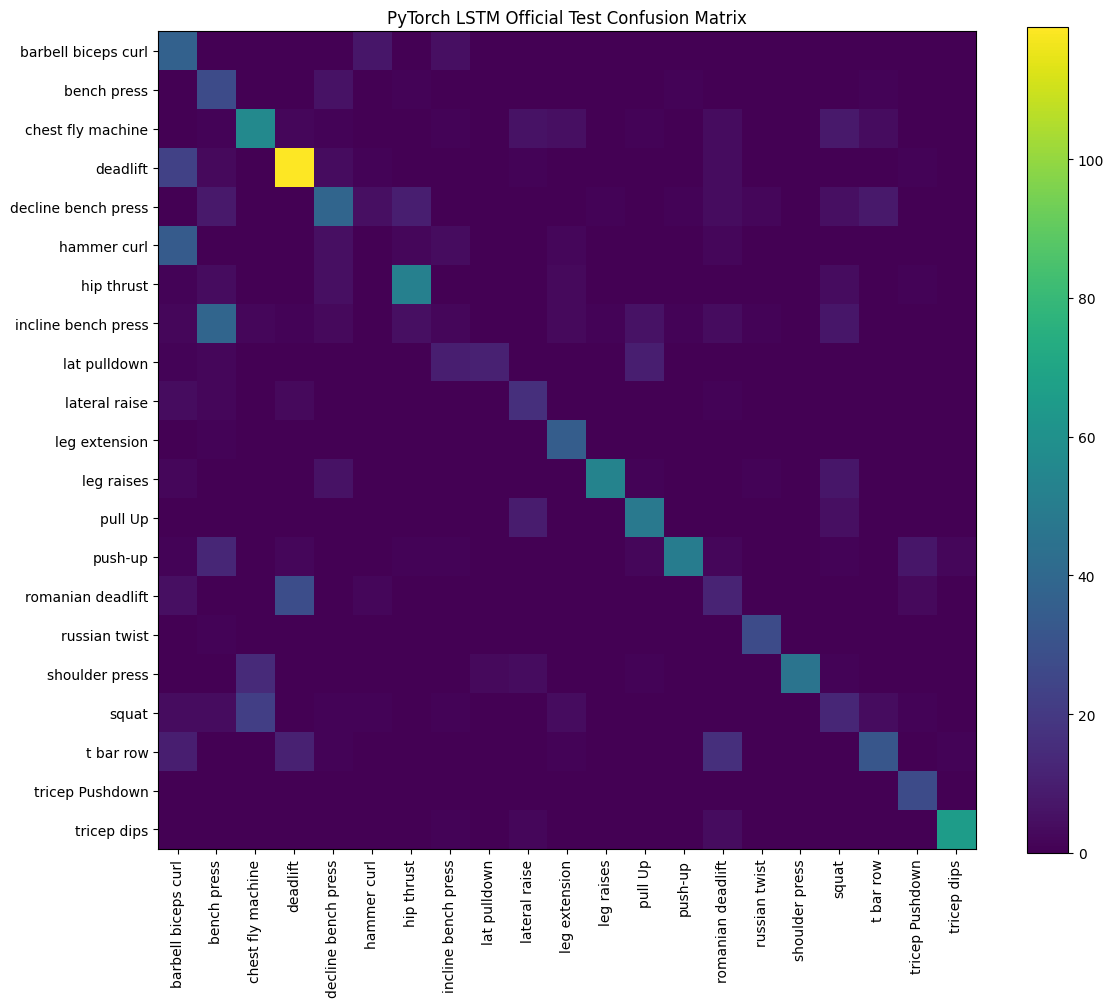

In [ ]:
# ============================================================
# 12. Save final test report + confusion matrix
# ============================================================
test_report = classification_report(
    test_labels,
    test_preds,
    target_names=label_names,
    zero_division=0,
    output_dict=True
)

test_report_df = pd.DataFrame(test_report).transpose()

TEST_REPORT_PATH = os.path.join(OUTPUT_RESULT_DIR, "torch_lstm_official_test_report.csv")
test_report_df.to_csv(TEST_REPORT_PATH)
display(test_report_df)

test_cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(12, 10))
plt.imshow(test_cm)
plt.title("PyTorch LSTM Official Test Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(label_names)), label_names, rotation=90)
plt.yticks(range(len(label_names)), label_names)
plt.tight_layout()

TEST_CM_PATH = os.path.join(OUTPUT_GRAPH_DIR, "torch_lstm_official_test_confusion_matrix.png")
plt.savefig(TEST_CM_PATH, dpi=200, bbox_inches="tight")
plt.show()

np.save(os.path.join(OUTPUT_RESULT_DIR, "torch_lstm_official_test_confusion_matrix.npy"), test_cm)

In [ ]:
# ============================================================
# 13. Save PyTorch checkpoint + scaler + labels
# ============================================================
CHECKPOINT_PATH = os.path.join(OUTPUT_MODEL_DIR, "best_workout_lstm_model.pth")

checkpoint = {
    "model_state_dict": final_model.cpu().state_dict(),
    "hyperparams": {
        "input_size": FEATURE_SIZE,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "num_classes": num_classes,
        "dropout": DROPOUT,
        "sequence_length": SEQUENCE_LENGTH
    },
    "label_names": label_names,
    "test_accuracy": test_acc,
    "test_macro_f1": test_macro,
    "test_weighted_f1": test_weighted
}

torch.save(checkpoint, CHECKPOINT_PATH)

SCALER_JSON_PATH = os.path.join(OUTPUT_MODEL_DIR, "mediapipe_scaler.json")
with open(SCALER_JSON_PATH, "w") as f:
    json.dump({
        "mean": final_scaler.mean_.tolist(),
        "scale": final_scaler.scale_.tolist()
    }, f)

LABEL_PATH = os.path.join(OUTPUT_MODEL_DIR, "label_names.json")
with open(LABEL_PATH, "w") as f:
    json.dump(label_names, f)

print("Saved checkpoint:", CHECKPOINT_PATH)
print("Saved scaler:", SCALER_JSON_PATH)
print("Saved labels:", LABEL_PATH)

Saved checkpoint: /content/drive/MyDrive/UChicago/Masters/Spring/Computer Vision/Computer Vision Final Project/mediapipe_pose_exercise_new_dataset/torch_lstm_coreml/best_workout_lstm_model_new_dataset.pth
Saved scaler: /content/drive/MyDrive/UChicago/Masters/Spring/Computer Vision/Computer Vision Final Project/mediapipe_pose_exercise_new_dataset/torch_lstm_coreml/mediapipe_scaler.json
Saved labels: /content/drive/MyDrive/UChicago/Masters/Spring/Computer Vision/Computer Vision Final Project/mediapipe_pose_exercise_new_dataset/torch_lstm_coreml/label_names.json


In [ ]:
# ============================================================
# 14. Convert final PyTorch model to CoreML
# ============================================================
export_model = WorkoutClassifierLSTM(
    input_size=FEATURE_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=num_classes,
    dropout=DROPOUT
)

export_model.load_state_dict(checkpoint["model_state_dict"])
export_model.eval()

example_input = torch.rand(1, SEQUENCE_LENGTH, FEATURE_SIZE)

with torch.no_grad():
    example_output = export_model(example_input)

print("Example input:", example_input.shape)
print("Example output:", example_output.shape)

traced_model = torch.jit.trace(export_model, example_input)

coreml_model = ct.convert(
    traced_model,
    inputs=[
        ct.TensorType(
            name="input",
            shape=example_input.shape
        )
    ],
    outputs=[
        ct.TensorType(name="logits")
    ],
    convert_to="mlprogram",
    minimum_deployment_target=ct.target.iOS15
)

COREML_PATH = os.path.join(OUTPUT_MODEL_DIR, "WorkoutClassifierLSTM.mlpackage")
coreml_model.save(COREML_PATH)

print("Saved CoreML model:", COREML_PATH)

Example input: torch.Size([1, 48, 300])
Example output: torch.Size([1, 21])


Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 1069.61 passes/s]


Saved CoreML model: /content/drive/MyDrive/UChicago/Masters/Spring/Computer Vision/Computer Vision Final Project/mediapipe_pose_exercise_new_dataset/torch_lstm_coreml/WorkoutClassifierLSTM.mlpackage
